# 01 -- Synthetic Data Generation
### Nectar Intelligent Facilities Platform

This notebook drives `src/nectar/data_generation.py` (weather + physics-grounded
telemetry + asset hierarchy + intentional data-quality fixtures) end to end and
sanity-checks the output. See `docs/data_dictionary.md` for the full unit/range/
standard reference per asset type, and `PLAN.md` for the design rationale.

All generation is seeded (`SEED=42`) -- rerunning this notebook always reproduces
byte-identical output.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
from nectar import config, data_generation, weather as weather_mod
pd.set_option('display.max_columns', 20)

## 1. Generate all four raw datasets

In [2]:
result = data_generation.generate_all(save=True)
telemetry, metadata, connectivity, weather_df = (
    result['telemetry'], result['metadata'], result['connectivity'], result['weather'])
dq_issues = result['dq_issues']
print(f"telemetry: {telemetry.shape} | metadata: {metadata.shape} | "
      f"connectivity: {connectivity.shape} | weather: {weather_df.shape}")

22:49:12 | INFO    | nectar.weather | Generated weather: 38,880 rows across 3 sites, 2025-01-01 00:00:00 -> 2025-03-31 23:50:00


22:49:12 | INFO    | nectar.data_generation | Built metadata: 149 assets across 9 buildings; 140 connectivity edges


22:49:12 | INFO    | nectar.data_generation | Injected DQ issues: {'orphan_assets': ['CHN-ISO-001', 'CBE-ISO-002'], 'invalid_parent': [('CHN-B2-CHL-01', 'CHN-B2-GHOST-001'), ('CHN-B2-MTR-MAIN-01', 'CHN-B2-MTR-GHOST-002')], 'duplicate_edges': [['CHN-B1-AHU-04', 'CHN-B1-EVS-04']], 'missing_relationships': [['CHN-B3-CHL-02', 'CHN-B3-AHU-05'], ['BLR-B2-AHU-05', 'BLR-B2-EVS-05']]}


22:49:18 | INFO    | nectar.data_generation | Generated telemetry: 1,956,960 rows, 151 assets, fault_flag rate 0.079%, 129 fault episodes


22:49:19 | INFO    | nectar.weather | Saved weather.csv -> D:\nectar-intelligent-facilities-platform\data\raw\weather.csv


22:49:34 | INFO    | nectar.data_generation | Saved 4 raw datasets -> D:\nectar-intelligent-facilities-platform\data\raw


telemetry: (1956960, 12) | metadata: (151, 9) | connectivity: (139, 4) | weather: (38880, 4)


## 2. Weather sanity check -- per-site seasonal + diurnal shape

22:49:35 | INFO    | nectar.weather | Saved weather sanity plot -> D:\nectar-intelligent-facilities-platform\reports\figures\00_weather_sanity.png


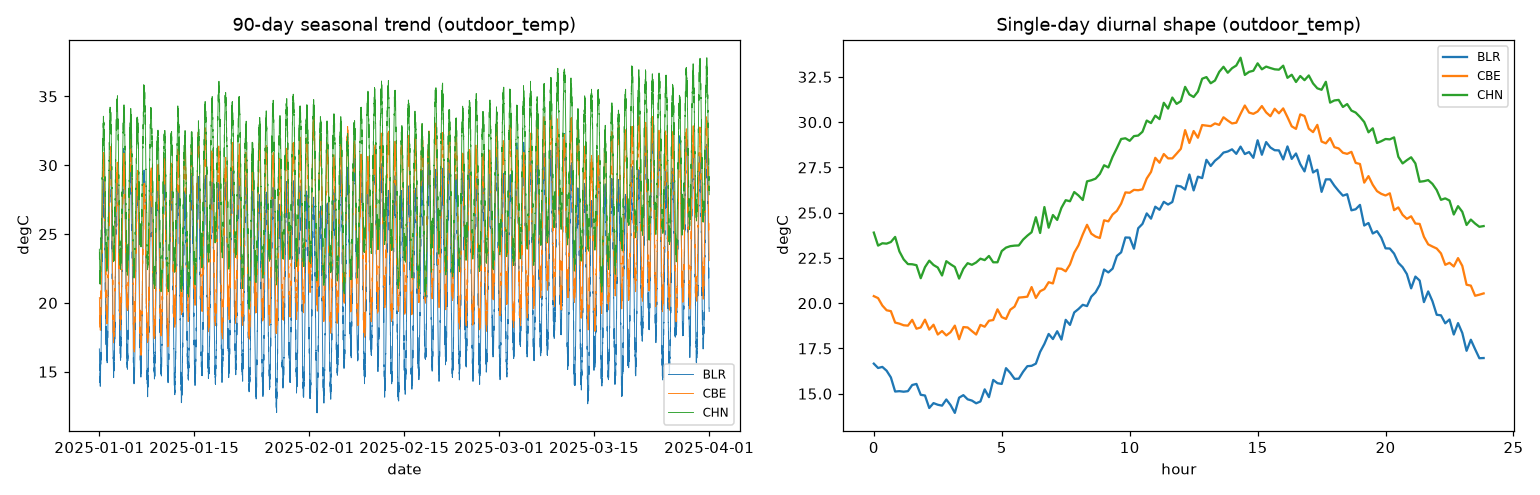

In [3]:
weather_mod.plot_weather_sanity_check(weather_df)
from IPython.display import Image
Image(os.path.join(config.FIGURES_DIR, '00_weather_sanity.png'))

## 3. Asset hierarchy composition

In [4]:
print(metadata.groupby(['site_id','building_id','asset_type']).size().unstack(fill_value=0))
print(f"\nTotal assets: {len(metadata)} | Connectivity edges: {len(connectivity)}")

asset_type           AHU  Chiller  EnergyMeter  EnvSensor  Pump
site_id building_id                                            
BLR     BLR-B1         5        2            3          5     2
        BLR-B2         5        2            3          5     2
        BLR-B3         4        2            3          4     2
CBE     CBE-B1         5        2            3          5     2
        CBE-B2         5        2            3          5     2
        CBE-B3         4        2            3          5     2
CHN     CHN-B1         4        2            3          4     2
        CHN-B2         6        2            4          6     2
        CHN-B3         5        2            3          5     2

Total assets: 151 | Connectivity edges: 139


## 4. Intentional data-quality fixtures

Injected deliberately so Task 5's DQ audit (`notebooks/06_connectivity_analysis.ipynb`)
has genuine findings to report, not a clean graph with nothing to say.

In [5]:
dq_issues

{'orphan_assets': ['CHN-ISO-001', 'CBE-ISO-002'],
 'invalid_parent': [('CHN-B2-CHL-01', 'CHN-B2-GHOST-001'),
  ('CHN-B2-MTR-MAIN-01', 'CHN-B2-MTR-GHOST-002')],
 'duplicate_edges': [['CHN-B1-AHU-04', 'CHN-B1-EVS-04']],
 'missing_relationships': [['CHN-B3-CHL-02', 'CHN-B3-AHU-05'],
  ['BLR-B2-AHU-05', 'BLR-B2-EVS-05']]}

## 5. Per-asset-type signal sanity (physical plausibility spot-check)

In [6]:
merged = telemetry.merge(metadata[['asset_id','asset_type']], on='asset_id')
merged.groupby('asset_type')[['temperature','pressure','vibration','power_consumption']].describe().round(2).T

asset_type                     AHU    Chiller  EnergyMeter  EnvSensor  \
temperature       count  544377.00  227721.00    354364.00  556768.00   
                  mean       16.27       8.02        28.00      23.13   
                  std         0.98       0.71         1.00       0.94   
                  min        12.06       3.16        23.15      17.31   
                  25%        15.64       7.51        27.32      22.50   
                  50%        16.38       8.15        28.00      23.11   
                  75%        16.98       8.52        28.67      23.73   
                  max        22.30      11.81        32.47      30.46   
pressure          count  544392.00  227936.00    354321.00  556927.00   
                  mean      350.32       7.42         1.00       1.00   
                  std        45.74       0.86         0.02       0.02   
                  min       211.19       2.62         0.90       0.91   
                  25%       316.50       6.78         0.99       0.99   
                  50%       341.89       7.22         1.00       1.00   
                  75%       378.69       7.96         1.01       1.01   
                  max       704.44      12.14         1.09       1.09   
vibration         count  544182.00  227877.00    354426.00  556812.00   
                  mean        1.89       2.79         0.05       0.02   
                  std         0.43       0.44         0.02       0.01   
                  min         0.63       1.32         0.00       0.00   
                  25%         1.63       2.48         0.04       0.01   
                  50%         1.84       2.76         0.05       0.02   
                  75%         2.09       3.08         0.06       0.03   
                  max         7.39       4.75         0.14       0.07   
power_consumption count  557280.00  233280.00    362880.00  570240.00   
                  mean        1.55      29.60        28.37       0.01   
                  std         2.91      47.17        82.65       0.00   
                  min         0.00       0.00         0.12       0.00   
                  25%         0.14       2.16         0.12       0.01   
                  50%         0.15       3.45         2.30       0.01   
                  75%         1.20      46.16         7.16       0.01   
                  max        42.42     513.13       776.59       0.08   

asset_type                    Pump  
temperature       count  227757.00  
                  mean       12.51  
                  std         0.80  
                  min         6.51  
                  25%        11.98  
                  50%        12.44  
                  75%        12.98  
                  max        19.25  
pressure          count  227694.00  
                  mean      282.33  
                  std        29.96  
                  min       184.13  
                  25%       260.08  
                  50%       277.45  
                  75%       301.62  
                  max       408.87  
vibration         count  227838.00  
                  mean        2.35  
                  std         0.53  
                  min         0.63  
                  25%         2.03  
                  50%         2.30  
                  75%         2.60  
                  max         7.24  
power_consumption count  233280.00  
                  mean        1.40  
                  std         2.40  
                  min         0.12  
                  25%         0.12  
                  50%         0.14  
                  75%         1.51  
                  max        41.81

## 6. Fault ramp sanity check

Spot-check that a fault event is preceded by a genuine multi-hour degradation
ramp (not a step function) -- this is the signal Task 2's predictive-maintenance
model depends on.

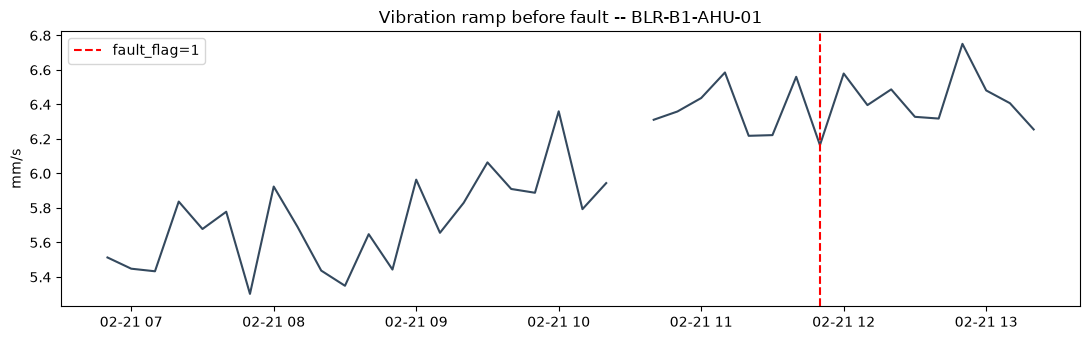

In [7]:
faulty = telemetry[telemetry.fault_flag == 1]
example_asset = faulty['asset_id'].iloc[0]
ex = telemetry[telemetry.asset_id == example_asset].sort_values('timestamp').reset_index(drop=True)
fault_idx = ex.index[ex.fault_flag == 1][0]
window = ex.iloc[max(0, fault_idx-30):fault_idx+10]
fig, ax = plt.subplots(figsize=(11,3.5))
ax.plot(window['timestamp'], window['vibration'], color='#34495e')
ax.axvline(ex.loc[fault_idx,'timestamp'], color='red', ls='--', label='fault_flag=1')
ax.set(title=f'Vibration ramp before fault -- {example_asset}', ylabel='mm/s')
ax.legend(); plt.tight_layout(); plt.show()